# Jackknife Example

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/jackknife_example.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-22*

## Learning objectives

- Apply *jackknife resampling* — systematically leaving out one observation at a time — to estimate uncertainty in a linear regression slope and intercept.
- Build a distribution of slopes/intercepts from the leave-one-out fits and read percentile-based uncertainty bounds from it.
- Visualize the resulting envelope of best-fit lines around the data.


Jackknife resampling is one of the simplest ways to put error bars on a quantity computed from a sample: leave one data point out, recompute, replace it, and repeat for every point. The spread of those leave-one-out estimates becomes your uncertainty.

Below we use it on the **North Atlantic Oscillation (NAO)** January time series to get uncertainty bounds on the slope and y-intercept of a linear trend.


In [1]:
try:
    import google.colab

    IN_COLAB = True
except ImportError:
    IN_COLAB = False
print(f"IN_COLAB = {IN_COLAB}")

IN_COLAB = False


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

## Load the data

We load the [North Atlantic Oscillation (NAO)](https://en.wikipedia.org/wiki/North_Atlantic_oscillation) time series and keep January values only (the first column).


In [3]:
if IN_COLAB:
    !pip install wget
    import wget

    filename = wget.download(
        "https://raw.githubusercontent.com/eabarnes1010/course_objective_analysis/main/data/nao_timeseries.mat"
    )
else:
    filename = "../data/nao_timeseries.mat"

DATA = sio.loadmat(filename)
X = DATA["NAO"][:, 0]  # January NAO values
TIME_NAO = DATA["TIME_NAO"][:, 0]
del DATA

## Look at the data

As always, plot the data first. We overlay the best-fit line through all of the points.


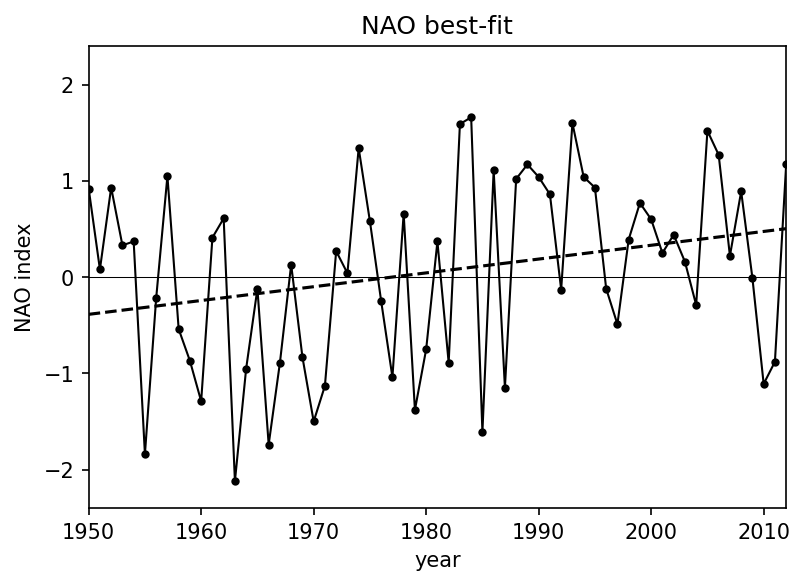

In [4]:
plt.figure()
plt.plot(TIME_NAO, X, ".-", color="black", linewidth=1.0)

pfull = np.polyfit(TIME_NAO, X, 1)
plt.plot(TIME_NAO, TIME_NAO * pfull[0] + pfull[1], "--", color="black")

plt.xlabel("year")
plt.ylabel("NAO index")
plt.ylim(-2.4, 2.4)
plt.xlim(min(TIME_NAO), max(TIME_NAO))
plt.title("NAO best-fit")
plt.axhline(y=0, linewidth=0.5, color="black")
plt.axvline(x=0, linewidth=0.5, color="black")
plt.show()

What are the slope and y-intercept of that all-data best-fit line?


In [5]:
slope = pfull[0]
yint = pfull[1]
print(f"slope = {slope}, y-intercept = {yint}")

slope = 0.014354838709677131, y-intercept = -28.37899897593389


## Jackknife resampling

How certain are we of those two numbers? One way to attack this question is [**jackknife resampling**](https://en.wikipedia.org/wiki/Jackknife_resampling):

1. Remove one data point.
2. Recompute the slope and y-intercept on the remaining points.
3. Save those values, put the point back, and move on to the next point.

After looping over all `len(X)` points we have `len(X)` slope/intercept pairs — a small distribution we can summarize.


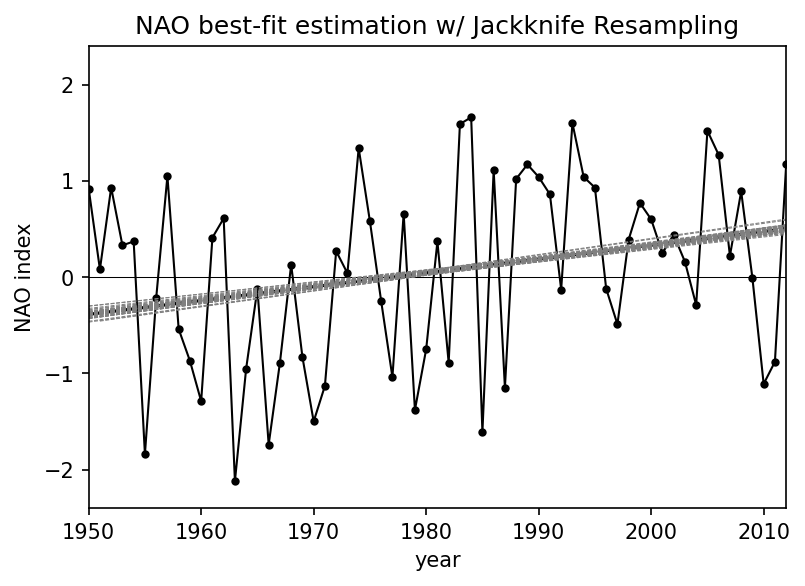

In [6]:
M = np.empty([len(X), 2])

plt.figure()
plt.plot(TIME_NAO, X, ".-", color="black", linewidth=1.0)
pfull = np.polyfit(TIME_NAO, X, 1)
plt.plot(TIME_NAO, TIME_NAO * pfull[0] + pfull[1], "--", color="black")

plt.xlabel("year")
plt.ylabel("NAO index")
plt.ylim(-2.4, 2.4)
plt.xlim(min(TIME_NAO), max(TIME_NAO))
plt.axhline(y=0, linewidth=0.5, color="black")
plt.axvline(x=0, linewidth=0.5, color="black")

for j, val in enumerate(X):
    X2 = np.delete(X, j)
    T2 = np.delete(TIME_NAO, j)

    pfull = np.polyfit(T2, X2, 1)
    M[j, 0] = pfull[0]
    M[j, 1] = pfull[1]

    plt.plot(T2, T2 * pfull[0] + pfull[1], "--", color="gray", linewidth=0.5)

    if j == 40:  # Save this iteration to highlight below.
        pfull_example = pfull
        val_example = val
        j_example = j

plt.title("NAO best-fit estimation w/ Jackknife Resampling")
plt.show()

Each gray dashed line is a different leave-one-out fit. To make that concrete, here's what happens when we leave out point 40 (highlighted in red):


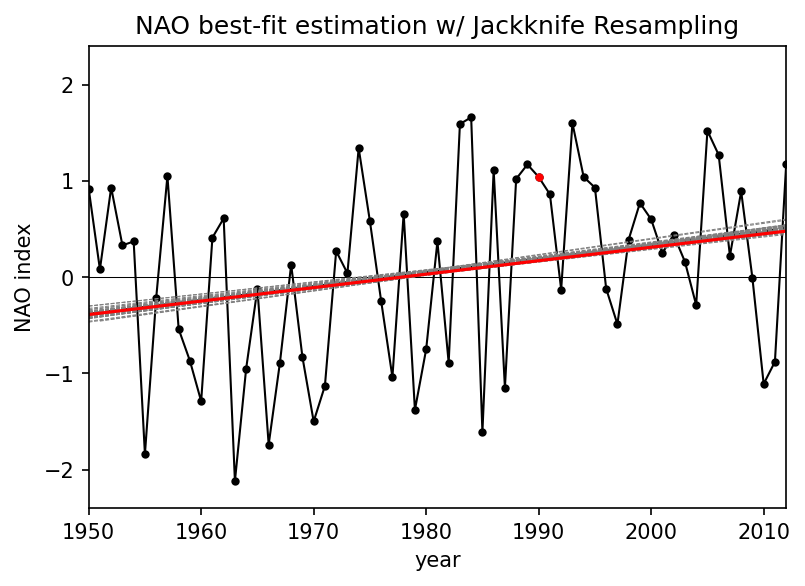

In [7]:
plt.figure()
plt.plot(TIME_NAO, X, ".-", color="black", linewidth=1.0)
pfull = np.polyfit(TIME_NAO, X, 1)
plt.plot(TIME_NAO, TIME_NAO * pfull[0] + pfull[1], "--", color="black")

plt.xlabel("year")
plt.ylabel("NAO index")
plt.ylim(-2.4, 2.4)
plt.xlim(min(TIME_NAO), max(TIME_NAO))
plt.axhline(y=0, linewidth=0.5, color="black")
plt.axvline(x=0, linewidth=0.5, color="black")

for j, val in enumerate(X):
    X2 = np.delete(X, j)
    T2 = np.delete(TIME_NAO, j)
    pfull = np.polyfit(T2, X2, 1)
    plt.plot(T2, T2 * pfull[0] + pfull[1], "--", color="gray", linewidth=0.5)

plt.title("NAO best-fit estimation w/ Jackknife Resampling")

# Highlight the j=40 leave-one-out fit and the omitted point.
T2 = np.delete(TIME_NAO, j_example)
plt.plot(TIME_NAO[j_example], val_example, ".", color="red")
plt.plot(T2, T2 * pfull_example[0] + pfull_example[1], "-", color="red", linewidth=1.5)
plt.show()

## Distributions of slope and y-intercept

We now have `len(X)` jackknife estimates of both the slope and the y-intercept. Plot a histogram of each.


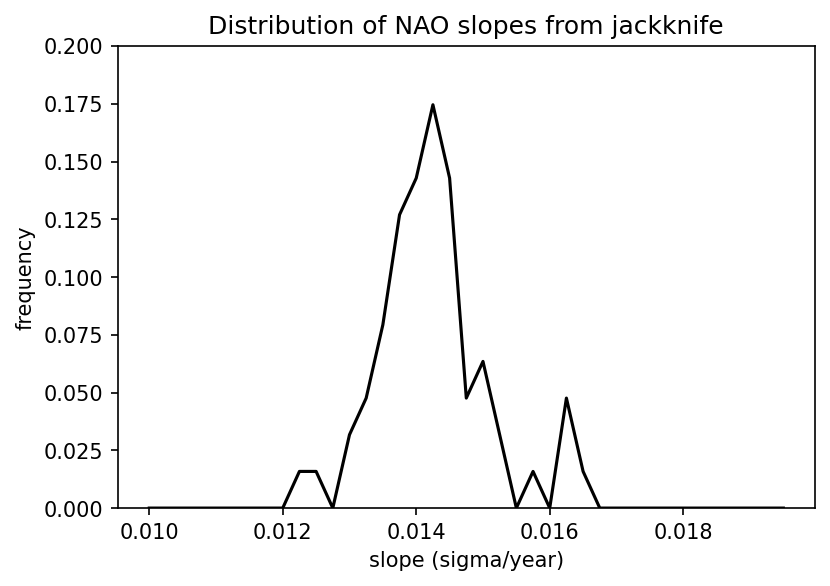

In [8]:
xint = np.arange(0.01, 0.02, 0.00025)
y, bin_edges = np.histogram(M[:, 0], xint)

plt.figure()
plt.plot(bin_edges[:-1], y / float(len(M)), color="black")
plt.ylim(0, 0.2)
plt.xlabel("slope (sigma/year)")
plt.ylabel("frequency")
plt.title("Distribution of NAO slopes from jackknife")
plt.show()

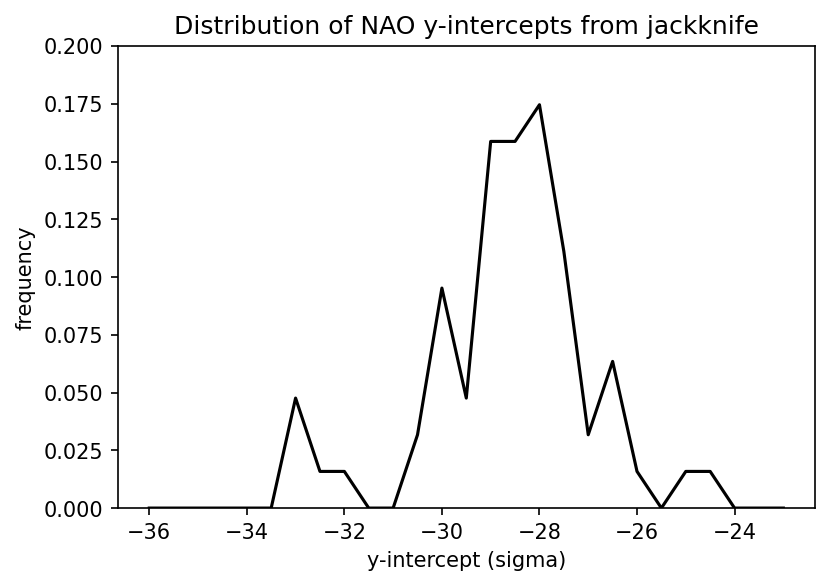

In [9]:
xint = np.arange(-36.0, -22.0, 0.5)
y, bin_edges = np.histogram(M[:, 1], xint)

plt.figure()
plt.plot(bin_edges[:-1], y / float(len(M)), color="black")
plt.ylim(0, 0.2)
plt.xlabel("y-intercept (sigma)")
plt.ylabel("frequency")
plt.title("Distribution of NAO y-intercepts from jackknife")
plt.show()

From each distribution we can read off a **best guess** (the mean of the leave-one-out estimates) and an **uncertainty range** (e.g. the 5th–95th percentile spread). The next two plots mark those on the histograms.


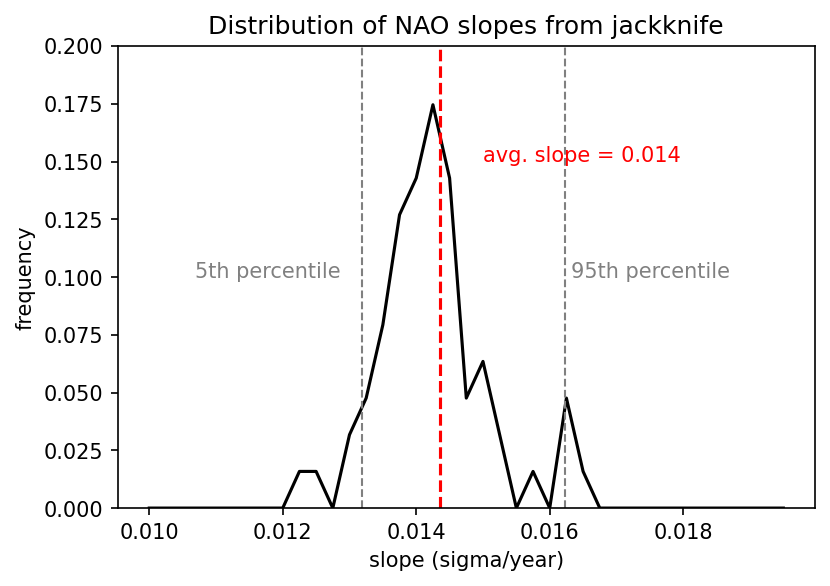

In [10]:
xint = np.arange(0.01, 0.02, 0.00025)
y, bin_edges = np.histogram(M[:, 0], xint)

plt.figure()
plt.plot(bin_edges[:-1], y / float(len(M)), color="black")
plt.ylim(0, 0.2)
plt.xlabel("slope (sigma/year)")
plt.ylabel("frequency")
plt.title("Distribution of NAO slopes from jackknife")

mean_slope = np.mean(M[:, 0])
plt.plot((mean_slope, mean_slope), (0, 0.2), "--r")
plt.text(0.015, 0.150, f"avg. slope = {np.around(mean_slope, 3)}", color="red")

perc95 = np.percentile(M[:, 0], 95)
perc5 = np.percentile(M[:, 0], 5)
plt.plot((perc95, perc95), (0, 0.2), "--", color="gray", linewidth=1)
plt.text(perc95 + 0.0001, 0.10, "95th percentile", color="gray")
plt.plot((perc5, perc5), (0, 0.2), "--", color="gray", linewidth=1)
plt.text(perc5 - 0.0025, 0.10, "5th percentile", color="gray")
plt.show()

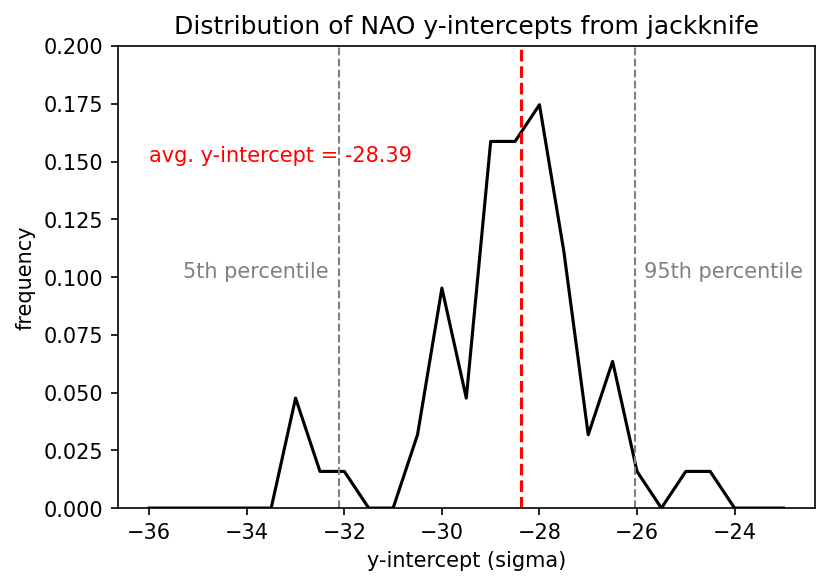

In [11]:
xint = np.arange(-36.0, -22.0, 0.5)
y, bin_edges = np.histogram(M[:, 1], xint)

plt.figure()
plt.plot(bin_edges[:-1], y / float(len(M)), color="black")
plt.ylim(0, 0.2)
plt.xlabel("y-intercept (sigma)")
plt.ylabel("frequency")
plt.title("Distribution of NAO y-intercepts from jackknife")

mean_yint = np.mean(M[:, 1])
plt.plot((mean_yint, mean_yint), (0, 0.2), "--r")
plt.text(-36, 0.150, f"avg. y-intercept = {np.around(mean_yint, 2)}", color="red")

perc95 = np.percentile(M[:, 1], 95)
perc5 = np.percentile(M[:, 1], 5)
plt.plot((perc95, perc95), (0, 0.2), "--", color="gray", linewidth=1)
plt.text(perc95 + 0.2, 0.10, "95th percentile", color="gray")
plt.plot((perc5, perc5), (0, 0.2), "--", color="gray", linewidth=1)
plt.text(perc5 - 3.2, 0.10, "5th percentile", color="gray")
plt.show()

Jackknife is just *one* approach to slope/intercept uncertainty. You don't see it used very often in practice, but it can be useful when you suspect one or two outliers are doing a lot of the work in setting the regression line — leaving each point out in turn shows exactly how sensitive the fit is to individual observations.


## Putting it all together

We can now plot the all-data best-fit line along with the **envelope** of all jackknife fits (the shaded band shows the min-to-max range across the leave-one-out fits at each year).

If you wanted to quote uncertainties for a paper, you could report 95% bounds:

* slope: $0.013 \le m \le 0.016$
* y-intercept: $-32.1 \le b \le -26.05$


In [12]:
best_fit_lines = np.zeros((len(M), len(TIME_NAO)))
for i in np.arange(0, len(M)):
    best_fit_lines[i, :] = TIME_NAO * M[i, 0] + M[i, 1]

best_fit_lines_min = np.min(best_fit_lines, axis=0)
best_fit_lines_max = np.max(best_fit_lines, axis=0)

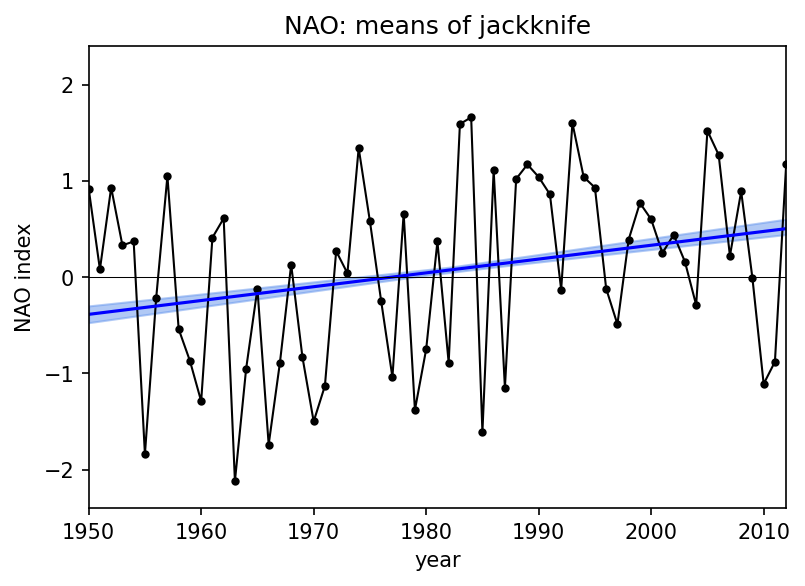

In [13]:
plt.figure()
plt.plot(TIME_NAO, X, ".-", color="black", linewidth=1.0)
plt.plot(TIME_NAO, TIME_NAO * mean_slope + mean_yint, "-", color="blue", linewidth=1.5)
plt.fill_between(
    TIME_NAO, best_fit_lines_min, best_fit_lines_max, color="cornflowerblue", alpha=0.5
)
plt.xlabel("year")
plt.ylabel("NAO index")
plt.ylim(-2.4, 2.4)
plt.xlim(min(TIME_NAO), max(TIME_NAO))
plt.title("NAO: means of jackknife")
plt.axhline(y=0, linewidth=0.5, color="black")
plt.axvline(x=0, linewidth=0.5, color="black")
plt.show()

## Wrap-up

- Jackknife resampling recomputes a statistic with each observation left out in turn, producing a small distribution of leave-one-out estimates.
- For a linear fit this gives a distribution of slopes and y-intercepts; their mean is the best estimate and their 5th–95th percentile spread is a quick uncertainty range.
- The envelope of leave-one-out fits visualizes how much each individual point moves the regression line — useful when you're worried about a small number of outliers.
